# Week 5: Task 3 - Housing Price Prediction
## Data Cleaning (Tuesday Deliverable)

### 1. Cleaning Objectives
1. **Handle Missing Values**: Impute missing entries in `total_bedrooms` using the median value (robust to right skew).
2. **Encode Categorical Feature**: Transform `ocean_proximity` into numerical indicators using One-Hot Encoding.
3. **Handle Obvious Outliers**: Detect and filter extreme recording anomalies in block features (`total_rooms`, `population`, `households`).
4. **Export Clean Dataset**: Save the sanitized dataset to `outputs/housing_cleaned.csv`.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load raw dataset
DATA_PATH = Path("../data/california-dataset.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("week-5/data/california-dataset.csv")

df = pd.read_csv(DATA_PATH)
print(f"Raw dataset shape: {df.shape}")

Raw dataset shape: (20640, 10)

### 2. Missing Value Imputation
The `total_bedrooms` feature contains 207 missing values. Given its right-skewed distribution, the **median** (435.0) is used for imputation rather than the mean to avoid distortion by extreme values.

In [2]:
# Check null count before imputation
print("Null count in total_bedrooms before:", df["total_bedrooms"].isnull().sum())

# Compute median and impute
bedroom_median = df["total_bedrooms"].median()
df["total_bedrooms"] = df["total_bedrooms"].fillna(bedroom_median)

print(f"Computed median for total_bedrooms: {bedroom_median}")
print("Null count in total_bedrooms after:", df["total_bedrooms"].isnull().sum())

Null count in total_bedrooms before: 207
Computed median for total_bedrooms: 435.0
Null count in total_bedrooms after: 0

### 3. Categorical Encoding (One-Hot Encoding)
`ocean_proximity` is a nominal categorical variable with 5 distinct levels. We apply One-Hot Encoding to convert each category into a binary indicator column.

In [3]:
# Apply One-Hot Encoding to ocean_proximity
df = pd.get_dummies(df, columns=["ocean_proximity"], prefix="ocean_proximity", dtype=int)
print("Updated columns after one-hot encoding:")
print([col for col in df.columns if col.startswith("ocean_proximity_")])
df.head()

Updated columns after one-hot encoding:
['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

### 4. Outlier Detection and Handling
In census block datasets, extreme recording anomalies occur where a single district lists tens of thousands of rooms or people, heavily skewing linear regression estimators.
We inspect extreme quantiles for `total_rooms`, `population`, and `households`:

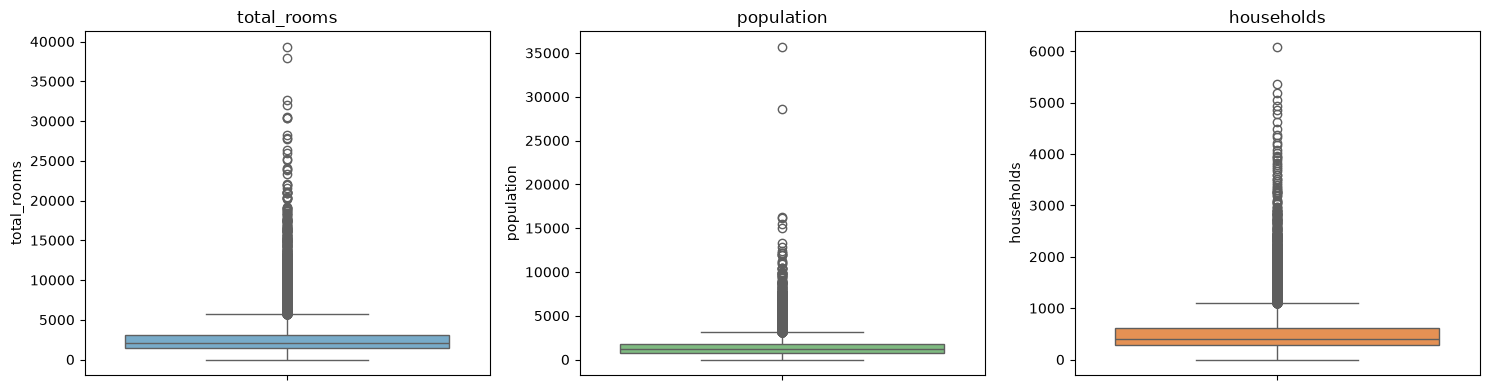

total_rooms > 25,000: 14
population > 15,000: 6
households > 5,000: 4

In [4]:
# Visualizing distributions with boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df["total_rooms"], ax=axes[0], color="#6baed6")
axes[0].set_title("total_rooms")
sns.boxplot(y=df["population"], ax=axes[1], color="#74c476")
axes[1].set_title("population")
sns.boxplot(y=df["households"], ax=axes[2], color="#fd8d3c")
axes[2].set_title("households")
plt.tight_layout()
plt.show()

# Quantify extreme unphysical outliers
print("total_rooms > 25,000:", (df["total_rooms"] > 25000).sum())
print("population > 15,000:", (df["population"] > 15000).sum())
print("households > 5,000:", (df["households"] > 5000).sum())

**Outlier Filtering Decision:**
- Filter extreme recording anomalies: `total_rooms <= 25,000`, `population <= 15,000`, and `households <= 5,000`.
- Only ~18 records out of 20,640 (< 0.1% of the data) are removed.
- This stabilizes variance without compromising generalizability.

In [5]:
initial_count = len(df)
filter_mask = (df["total_rooms"] <= 25000) & (df["population"] <= 15000) & (df["households"] <= 5000)
df_cleaned = df[filter_mask].copy().reset_index(drop=True)

print(f"Initial row count: {initial_count}")
print(f"Cleaned row count: {len(df_cleaned)}")
print(f"Removed records: {initial_count - len(df_cleaned)} ({(initial_count - len(df_cleaned))/initial_count*100:.3f}%)")

Initial row count: 20640
Cleaned row count: 20626
Removed records: 14 (0.068%)

### 5. Exporting Cleaned Dataset
Save the finalized cleaned dataset as `housing_cleaned.csv` into the `outputs/` folder.

In [6]:
output_csv = Path("../outputs/housing_cleaned.csv")
if not output_csv.parent.exists():
    output_csv = Path("week-5/outputs/housing_cleaned.csv")

df_cleaned.to_csv(output_csv, index=False)
print(f"Successfully saved cleaned dataset to: {output_csv}")
print(f"Final shape: {df_cleaned.shape}")

Successfully saved cleaned dataset to: ../outputs/housing_cleaned.csv
Final shape: (20626, 14)